# Media Authenticity Detection - Xception (Transfer Learning)

**Model:** Xception — a deep depthwise separable CNN, pre-trained on ImageNet.

**Optimizations for CPU:**
- Image Size: 128×128 (reduced from 299×299 default to fit CPU)
- Batch Size: 8 (Xception is heavier than EfficientNet)
- Phase 1 (5 epochs): Only custom head trained — base frozen
- Phase 2 (10 epochs): Top 20 layers unfrozen and fine-tuned
- CPU thread tuning + auto-resume from checkpoint

In [1]:
import os, gc, re, glob, json, pickle
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import Xception
import matplotlib.pyplot as plt
import multiprocessing

print(f"TensorFlow: {tf.__version__}")

# CPU thread optimization
NUM_CORES = multiprocessing.cpu_count()
tf.config.threading.set_intra_op_parallelism_threads(NUM_CORES)
tf.config.threading.set_inter_op_parallelism_threads(NUM_CORES)
print(f"CPU cores: {NUM_CORES}")

# GPU check
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
    print("GPU detected. Mixed precision enabled.")
else:
    tf.config.set_visible_devices([], 'GPU')
    print("No GPU. CPU optimizations active.")

# Paths
BASE_DIR        = os.path.join("..", "data", "processed", "images")
MODEL_SAVE_PATH = os.path.join("..", "models", "xception_model.keras")
MODEL_PKL_PATH  = os.path.join("..", "models", "xception_model.pkl")
CHECKPOINT_DIR  = os.path.join("..", "models", "checkpoints_xception")
STATE_FILE      = os.path.join(CHECKPOINT_DIR, "training_state.json")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Hyperparameters — tuned for CPU
IMAGE_SIZE   = (128, 128)   # Default is 299x299, reduced for CPU speed
BATCH_SIZE   = 8            # Xception is large; keep batch small
EPOCHS_HEAD  = 5            # Phase 1: Train head only
EPOCHS_FINE  = 10           # Phase 2: Fine-tune top layers

print(f"Image: {IMAGE_SIZE}, Batch: {BATCH_SIZE}")
print(f"Steps/epoch (approx): {70000 // BATCH_SIZE}")

TensorFlow: 2.21.0
CPU cores: 12
No GPU. CPU optimizations active.
Image: (128, 128), Batch: 8
Steps/epoch (approx): 8750


## Helper Utilities (Resume + State Tracking)

In [2]:
def find_latest_checkpoint(phase):
    pattern = os.path.join(CHECKPOINT_DIR, f"xception_{phase}_epoch_*.keras")
    files = glob.glob(pattern)
    if not files:
        return None, 0
    def get_epoch(f):
        m = re.search(r'epoch_(\d+)\.keras', os.path.basename(f))
        return int(m.group(1)) if m else 0
    files.sort(key=get_epoch)
    latest = files[-1]
    return latest, get_epoch(latest)

def load_training_state():
    if os.path.exists(STATE_FILE):
        with open(STATE_FILE, 'r') as f:
            state = json.load(f)
        print(f"[State] Loaded: {state}")
        return state
    print("[State] No state file. Starting from scratch.")
    return {"phase": "p1", "last_completed_epoch": 0}

def save_training_state(phase, epoch, best_val_loss=None):
    state = {"phase": phase, "last_completed_epoch": epoch}
    if best_val_loss is not None:
        state["best_val_loss"] = round(float(best_val_loss), 6)
    with open(STATE_FILE, 'w') as f:
        json.dump(state, f, indent=2)

class StateLogger(tf.keras.callbacks.Callback):
    def __init__(self, phase, initial_epoch=0):
        super().__init__()
        self.phase = phase
        self.initial_epoch = initial_epoch
    def on_epoch_end(self, epoch, logs=None):
        abs_epoch = self.initial_epoch + epoch + 1
        save_training_state(self.phase, abs_epoch, logs.get('val_loss') if logs else None)
        print(f"  [StateLogger] phase={self.phase}, epoch={abs_epoch}")

print("Helpers loaded.")

Helpers loaded.


## 1. Data Loading

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'train'), image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE, label_mode='binary')

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'val'), image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE, label_mode='binary')

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'test'), image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE, label_mode='binary')

AUTOTUNE = tf.data.AUTOTUNE
class_names = train_ds.class_names  # save before prefetch wraps the dataset
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

gc.collect()
print(f"Classes: {class_names}")

Found 70000 files belonging to 2 classes.
Found 15000 files belonging to 2 classes.
Found 15000 files belonging to 2 classes.
Classes: ['fake', 'real']


## 2. Build Model

In [4]:
base_model = Xception(
    include_top=False,
    weights='imagenet',
    input_shape=(128, 128, 3)
)
base_model.trainable = False

# Preprocessing for Xception: expects pixels in [-1, 1]
inputs  = tf.keras.Input(shape=(128, 128, 3))
x       = tf.keras.applications.xception.preprocess_input(inputs)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"Base trainable: {base_model.trainable}")
print(f"Total params: {model.count_params():,}")

Base trainable: False
Total params: 21,386,281


## 3. Phase 1 — Head Training (Resume-Aware)

In [5]:
state = load_training_state()
p1_checkpoint, _ = find_latest_checkpoint("p1")
p1_initial_epoch = state["last_completed_epoch"] if state["phase"] == "p1" else EPOCHS_HEAD

history_p1 = None
if p1_initial_epoch >= EPOCHS_HEAD:
    print(f"Phase 1 complete. Loading weights.")
    if p1_checkpoint:
        model.load_weights(p1_checkpoint)
        print(f"Loaded: {os.path.basename(p1_checkpoint)}")
else:
    if p1_checkpoint and p1_initial_epoch > 0:
        model.load_weights(p1_checkpoint)
        print(f"Resuming Phase 1 from epoch {p1_initial_epoch}")
    else:
        print("Starting Phase 1 from scratch.")

    checkpoint_p1 = callbacks.ModelCheckpoint(
        filepath=os.path.join(CHECKPOINT_DIR, "xception_p1_epoch_{epoch:02d}.keras"),
        save_best_only=True, monitor='val_loss', verbose=1)
    early_stop_p1 = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    state_logger_p1 = StateLogger(phase="p1", initial_epoch=p1_initial_epoch)

    print(f"=== Phase 1: Head training | Epochs: {p1_initial_epoch+1} → {EPOCHS_HEAD} ===")
    history_p1 = model.fit(
        train_ds, validation_data=val_ds,
        epochs=EPOCHS_HEAD, initial_epoch=p1_initial_epoch,
        callbacks=[early_stop_p1, checkpoint_p1, state_logger_p1]
    )
    save_training_state("p2", 0)
    gc.collect()
    print("Phase 1 complete.")

[State] Loaded: {'phase': 'p2', 'last_completed_epoch': 5, 'best_val_loss': 0.139212}
Phase 1 complete. Loading weights.
Loaded: xception_p1_epoch_05.keras


D:\Media Validate App\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## 4. Phase 2 — Fine-Tune Top 20 Layers (Resume-Aware)

Xception has ~126 layers. We unfreeze only the **last 20** at a 100x smaller LR.

In [6]:
# Always set up fine-tune architecture first
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Unfrozen layers: {trainable_count}/{len(base_model.layers)}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

state = load_training_state()
p2_checkpoint, p2_ckpt_epoch = find_latest_checkpoint("p2")
p2_initial_epoch = state["last_completed_epoch"] if state["phase"] == "p2" else 0

if p2_checkpoint and p2_initial_epoch > 0:
    model.load_weights(p2_checkpoint)
    print(f"Resuming Phase 2 from epoch {p2_initial_epoch} ({os.path.basename(p2_checkpoint)})")
elif p2_checkpoint and p2_ckpt_epoch > 0:
    model.load_weights(p2_checkpoint)
    p2_initial_epoch = p2_ckpt_epoch
    print(f"Resuming Phase 2 from checkpoint epoch {p2_initial_epoch}")
else:
    print("Starting Phase 2 from scratch.")

checkpoint_p2 = callbacks.ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, "xception_p2_epoch_{epoch:02d}.keras"),
    save_best_only=True, monitor='val_loss', verbose=1)
early_stop_p2 = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)
state_logger_p2 = StateLogger(phase="p2", initial_epoch=p2_initial_epoch)

print(f"=== Phase 2: Fine-tuning | Epochs: {p2_initial_epoch+1} → {EPOCHS_FINE} ===")
history_p2 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_FINE, initial_epoch=p2_initial_epoch,
    callbacks=[early_stop_p2, checkpoint_p2, reduce_lr, state_logger_p2]
)
gc.collect()
print("Phase 2 complete.")

Unfrozen layers: 20/132
[State] Loaded: {'phase': 'p2', 'last_completed_epoch': 5, 'best_val_loss': 0.139212}
Resuming Phase 2 from epoch 5 (xception_p2_epoch_03.keras)
=== Phase 2: Fine-tuning | Epochs: 6 → 10 ===
Epoch 6/10


D:\Media Validate App\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 56 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


8750/8750 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.9455 - loss: 0.1360
Epoch 6: val_loss improved from None to 0.12939, saving model to ..\models\checkpoints_xception\xception_p2_epoch_06.keras

Epoch 6: finished saving model to ..\models\checkpoints_xception\xception_p2_epoch_06.keras
  [StateLogger] phase=p2, epoch=11
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 5345s 610ms/step - accuracy: 0.9490 - loss: 0.1314 - val_accuracy: 0.9546 - val_loss: 0.1294 - learning_rate: 1.0000e-05
Epoch 7/10
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.9549 - loss: 0.1177
Epoch 7: val_loss did not improve from 0.12939
  [StateLogger] phase=p2, epoch=12
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 4795s 547ms/step - accuracy: 0.9557 - loss: 0.1139 - val_accuracy: 0.9555 - val_loss: 0.1334 - learning_rate: 1.0000e-05
Epoch 8/10
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.9624 - loss: 0.0980
Epoch 8: val_loss improved from 0.12939 to 0.12545, saving model to ..\models\checkpoints_xception\xcept

## 5. Evaluation & Save

In [7]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

model.save(MODEL_SAVE_PATH)
print(f"Model saved to {MODEL_SAVE_PATH}")

try:
    with open(MODEL_PKL_PATH, 'wb') as f:
        pickle.dump(model, f)
    print(f"Pickle saved to {MODEL_PKL_PATH}")
except Exception as e:
    print(f"Pickle failed: {e} (the .keras file is fully usable)")

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 617s 329ms/step - accuracy: 0.9598 - loss: 0.1233

Test Accuracy: 0.9598
Test Loss:     0.1233
Model saved to ..\models\xception_model.keras
Pickle saved to ..\models\xception_model.pkl


## 6. Training History Plot

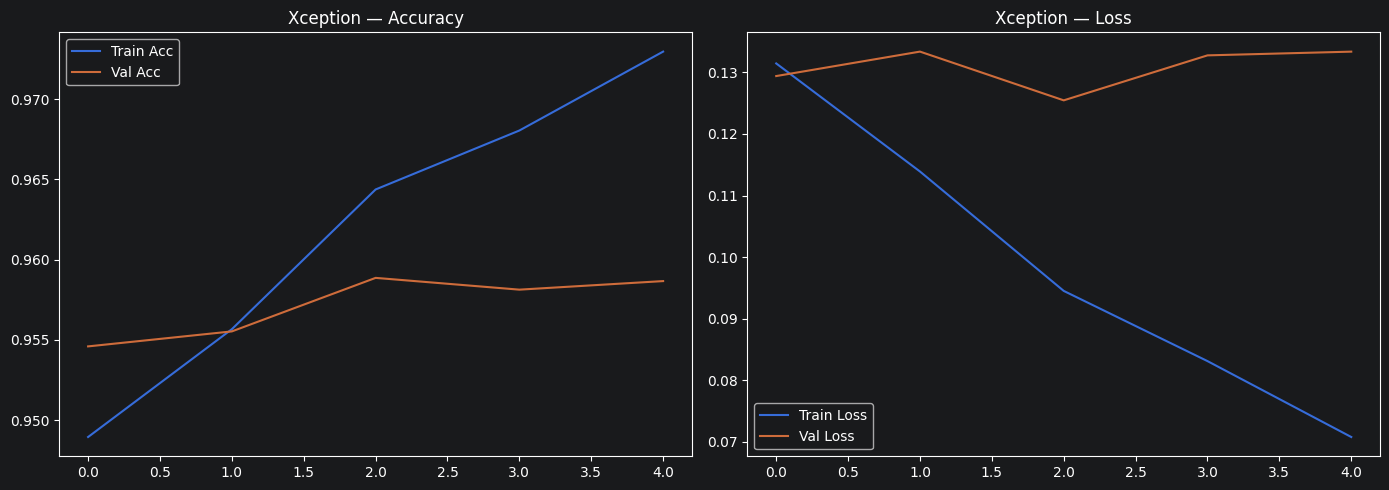

Plot saved.


In [8]:
p1_acc  = history_p1.history.get('accuracy', [])     if history_p1 else []
p1_loss = history_p1.history.get('loss', [])         if history_p1 else []
p1_va   = history_p1.history.get('val_accuracy', []) if history_p1 else []
p1_vl   = history_p1.history.get('val_loss', [])     if history_p1 else []

acc      = p1_acc  + history_p2.history.get('accuracy', [])
loss     = p1_loss + history_p2.history.get('loss', [])
val_acc  = p1_va   + history_p2.history.get('val_accuracy', [])
val_loss = p1_vl   + history_p2.history.get('val_loss', [])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(acc, label='Train Acc'); ax1.plot(val_acc, label='Val Acc')
if p1_acc: ax1.axvline(x=len(p1_acc)-1, color='r', linestyle='--', label='Fine-tune start')
ax1.set_title('Xception — Accuracy'); ax1.legend()

ax2.plot(loss, label='Train Loss'); ax2.plot(val_loss, label='Val Loss')
if p1_loss: ax2.axvline(x=len(p1_loss)-1, color='r', linestyle='--', label='Fine-tune start')
ax2.set_title('Xception — Loss'); ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join("..", "models", "xception_training_history.png"))
plt.show()
print("Plot saved.")